In [1]:
import matplotlib
matplotlib.rcParams['font.serif'] = ['Times'] + matplotlib.rcParams['font.serif']
matplotlib.rcParams['font.size'] = 6
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams["ps.usedistiller"] = 'xpdf'
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.weight'] = 'normal'
matplotlib.rcParams["mathtext.fontset"] = 'cm'

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import random
import math

import pandas as pd

import copy

import cvxpy
cp = cvxpy

import figurefirst as fifi

from braid_analysis import braid_analysis_plots
import fly_plot_lib.plot as fpl

import scipy.stats

/opt/anaconda3/envs/Python311/lib/python3.11/site-packages/figurefirst/mpl_fig_to_figurefirst_svg.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [5]:
import unifying_algo_analysis_helper as uaah
from set_zorder_functions import *

In [9]:
from align_course_direction_analysis import unifying_algo_analysis as uaa
from align_course_direction_analysis import unifying_algo_plots as uap

In [11]:
MARKERSIZE = 0.75
MODEL_LINE_COLOR = 'lightcoral'
TRANSLATION = True

In [13]:
FIGURE_NAME = 'unifying_analysis.svg'

In [15]:
if TRANSLATION:
    FIGURE_NAME = 'unifying_analysis_translationTrue.svg'

In [17]:
def get_median_slope_and_axis_ratio(fname):
    df = pd.read_parquet(fname)

    slopes = []
    axis_ratios = []
    rotation = []

    for obj_id in df.obj_id_unique_event.unique():
        data = df[df.obj_id_unique_event==obj_id].copy()
        #slopes.append(data.slope.abs().median())

        data['slope_abs'] = data.slope.abs()
        slopes.append( uaa.get_weighted_value(data, col='slope_abs', use='rmse_affine') )

        axis_ratios.append( uaa.get_weighted_value(data, col='axis_ratio', use='rmse_affine') )

        data.rotation = data.rotation.abs()
        rotation.append( uaa.get_weighted_value(data, col='rotation', use='rmse_affine') )

            
    results = {'slopes': np.array(slopes)/0.01,
               'axis_ratios': np.array(axis_ratios),
               'rotation': np.array(rotation),
               #'percent_affine_improvements': np.array(percent_affine_improvements),
              }
    
    return results

In [19]:
metadata = {'../unifying_algo_results/laminar_data_flash_translation' + str(TRANSLATION) + '.parquet': [1, '#991128ff', 'laminar'], 
            '../unifying_algo_results/unsteady_top_on_data_flash_translation' + str(TRANSLATION) + '.parquet': [2, '#2b75b3b3', 'unsteady'], 
            '../unifying_algo_results/stillair_data_flash_translation' + str(TRANSLATION) + '.parquet': [3, '#084a72ff', 'stillair'], 
           }

In [21]:
layout = fifi.svg_to_axes.FigureLayout(FIGURE_NAME, autogenlayers=True, make_mplfigures=True, hide_layers=[], dpi=600)
plt.close('all')

/opt/anaconda3/envs/Python311/lib/python3.11/site-packages/figurefirst/svg_to_axes.py:1041: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(fw_in, fh_in))


# Slopes

median slope:  3.957324214646105


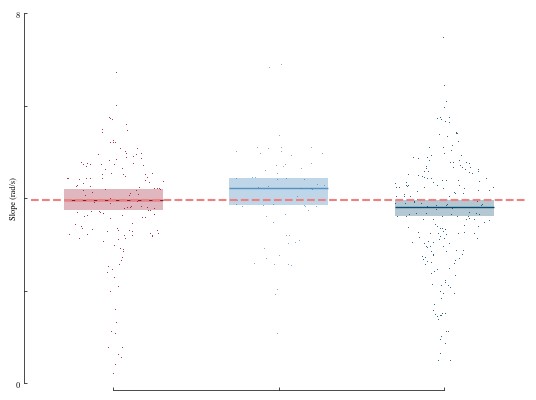

In [33]:
#ax = layout.axes[('flash_model', 'slopes')]
fig, ax = plt.subplots()
feature = 'slopes'

x_data_for_regression = []
y_data_for_regression = []

ticks = []
ticklabels = []

dpoints = []

for key, val in metadata.items():
    fname = key
    results = get_median_slope_and_axis_ratio(fname)
    xix, color, label = val

    ticks.append(xix)
    ticklabels.append(label)
    
    hist_counts, hist_bins = np.histogram(results[feature], bins=20)
    fpl.scatter_box_violin_distribution(ax, xix, copy.copy(results[feature]), hist_counts, hist_bins, color=color, markersize=MARKERSIZE)
    dpoints.append(results[feature])
    if xix<=3:
        x_data_for_regression.append(xix)
        y_data_for_regression.append(np.median(results[feature]))

print('median slope: ', np.median(y_data_for_regression))
median_slope = np.median(y_data_for_regression)
xixs = [1,2,3]
ax.hlines([median_slope,],
          xixs[0]-0.5, xixs[-1]+0.5, 
          linestyles=['--',], colors=[MODEL_LINE_COLOR,])

ax.set_xlim(0.5, 3.5)
ax.set_ylim(0,8)

ax.set_ylabel('Slope (rad/s)', labelpad=-2)


ax.set_xticks(ticks)
ax.set_xticklabels([])

ax.set_yticks([0, 2, 4, 6, 8])
ax.set_yticklabels(['$0$', '', '', '', '$8$'])

ax.tick_params(axis='y', pad=2)

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'],
                                 tick_length=2.5,
                                 spine_locations={'left': 5, 'bottom': 5},
                                 linewidth=0.5)
fifi.mpl_functions.set_fontsize(ax, 6)

plt.show()
# data = diagnose_axis_elements(ax, verbose=True)
set_selective_rasterization(ax, rasterize_markers=['o'])

#ax.set_rasterization_zorder(1000)

## Kruskal-Wallis H test 

In [39]:
scipy.stats.kruskal(dpoints[0], dpoints[1],dpoints[2])

KruskalResult(statistic=np.float64(5.75798854559207), pvalue=np.float64(0.056191247491521275))

# Axis Ratios

In [47]:
ax = layout.axes[('flash_model', 'axis_ratios')]

feature = 'axis_ratios'

x_data_for_regression = []
y_data_for_regression = []

ticks = []
ticklabels = []

dpoints = []

for key, val in metadata.items():
    fname = key
    results = get_median_slope_and_axis_ratio(fname)
    xix, color, label = val

    ticks.append(xix)
    ticklabels.append(label)
    dpoints.append(results[feature])    
    hist_counts, hist_bins = np.histogram(results[feature], bins=20)
    fpl.scatter_box_violin_distribution(ax, xix, copy.copy(results[feature]), hist_counts, hist_bins, color=color, markersize=MARKERSIZE)

    if xix<=3:
        x_data_for_regression.append(xix)
        y_data_for_regression.append(np.median(results[feature]))

result = scipy.stats.linregress(x_data_for_regression, y_data_for_regression)
axis_ratio_slope = result.slope
axis_ratio_intercept = result.intercept
x = np.linspace(x_data_for_regression[0]-0.5, x_data_for_regression[-1]+0.5, 10)
y = x*axis_ratio_slope + axis_ratio_intercept
ax.plot(x, y, '--', color=MODEL_LINE_COLOR)

print('axis ratios')
print(x_data_for_regression)
print(y_data_for_regression)

model_axis_ratio = {}
for key, val in metadata.items():
    fname = key
    results = get_median_slope_and_axis_ratio(fname)
    xix, color, label = val
    model_axis_ratio_for_condition = xix*axis_ratio_slope + axis_ratio_intercept
    model_axis_ratio.setdefault(fname, model_axis_ratio_for_condition)

print('axis_ratio_slope: ', axis_ratio_slope)
print('axis_ratio_intercept: ', axis_ratio_intercept)

ax.set_xlim(0.5, 3.5)
ax.set_ylim(0,1)

ax.set_ylabel('Axis ratio', labelpad=-2)

ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['$0$', '', '', '', '', '$1$'])

ax.set_xticks(ticks)
ax.set_xticklabels([])

ax.tick_params(axis='y', pad=2)

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'],
                                 tick_length=2.5,
                                 spine_locations={'left': 5, 'bottom': 5},
                                 linewidth=0.5)
fifi.mpl_functions.set_fontsize(ax, 6)
set_selective_rasterization(ax, rasterize_markers=['o'])

axis ratios
[1, 2, 3]
[np.float64(0.32584584695599406), np.float64(0.4460481609759775), np.float64(0.5605237784225934)]
axis_ratio_slope:  0.11733896573329966
axis_ratio_intercept:  0.209461330651589


In [59]:

"""
Paste this cell after the slope plotting cell (cell 61 in the notebook),
which ends with `set_selective_rasterization(ax, rasterize_markers=['o'])`.

It assumes `dpoints` is a list of 3 arrays: [laminar_slopes, unsteady_slopes, stillair_slopes],
which is built in that cell via `dpoints.append(results[feature])`.
"""

import numpy as np
import scipy.stats
from itertools import combinations

# =============================================================================
# Verify data is available
# =============================================================================
assert len(dpoints) == 3, f"Expected 3 conditions in dpoints, got {len(dpoints)}"
condition_labels = ['laminar', 'unsteady', 'stillair']

print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
for i, label in enumerate(condition_labels):
    d = dpoints[i]
    print(f"  {label:>10s}: n={len(d)}, mean={np.mean(d):.3f}, median={np.median(d):.3f}, sd={np.std(d):.3f}")

# =============================================================================
# TEST 1: Kruskal-Wallis (already in notebook, included for completeness)
# =============================================================================
kw_stat, kw_p = scipy.stats.kruskal(*dpoints)
print("\n" + "=" * 60)
print("TEST 1: Kruskal-Wallis (omnibus, no ordering)")
print("=" * 60)
print(f"  H = {kw_stat:.4f}")
print(f"  p = {kw_p:.2e}")

# =============================================================================
# TEST 2: Jonckheere-Terpstra (ordered trend: laminar < unsteady < stillair)
# =============================================================================
def jonckheere_terpstra(groups):
    """
    Jonckheere-Terpstra test for an increasing trend across ordered groups.
    groups: list of arrays in hypothesized order.
    """
    k = len(groups)
    J = 0
    for i, j in combinations(range(k), 2):
        for xi in groups[i]:
            for xj in groups[j]:
                if xj > xi:
                    J += 1
                elif xj == xi:
                    J += 0.5

    n = [len(g) for g in groups]
    N = sum(n)
    E_J = (N**2 - sum(ni**2 for ni in n)) / 4
    Var_J = (N**2 * (2 * N + 3) - sum(ni**2 * (2 * ni + 3) for ni in n)) / 72

    Z = (J - E_J) / np.sqrt(Var_J)
    p_one = 1 - scipy.stats.norm.cdf(Z)
    p_two = 2 * min(p_one, 1 - p_one)

    return J, E_J, Z, p_one, p_two

J, E_J, Z, p_one, p_two = jonckheere_terpstra(dpoints)

print("\n" + "=" * 60)
print("TEST 2: Jonckheere-Terpstra (ordered: laminar < unsteady < stillair)")
print("=" * 60)
print(f"  J = {J:.1f}")
print(f"  E[J] = {E_J:.1f}")
print(f"  Z = {Z:.4f}")
print(f"  p (one-sided, increasing) = {p_one:.2e}")
print(f"  p (two-sided) = {p_two:.2e}")

# =============================================================================
# TEST 3: OLS linear contrast
# =============================================================================
# Build arrays: condition_code (1,2,3) paired with each slope value
condition_codes = np.concatenate([np.full(len(dpoints[i]), i + 1) for i in range(3)])
all_slopes = np.concatenate(dpoints)

ols_result = scipy.stats.linregress(condition_codes, all_slopes)

print("\n" + "=" * 60)
print("TEST 3: OLS Linear Contrast (slope ~ condition_code)")
print("=" * 60)
print(f"  Regression slope = {ols_result.slope:.4f} rad/s per condition step")
print(f"  Intercept = {ols_result.intercept:.4f}")
print(f"  R² = {ols_result.rvalue**2:.4f}")
print(f"  p = {ols_result.pvalue:.2e}")

# =============================================================================
# TEST 4: Permutation test for linear trend
# =============================================================================
def permutation_trend_test(condition_codes, values, n_perms=10000, seed=42):
    """
    Permutation-based test: shuffle condition labels, recompute regression slope.
    """
    rng = np.random.default_rng(seed)
    observed_slope = np.polyfit(condition_codes, values, 1)[0]

    null_slopes = np.empty(n_perms)
    for i in range(n_perms):
        shuffled = rng.permutation(condition_codes)
        null_slopes[i] = np.polyfit(shuffled, values, 1)[0]

    p_two = np.mean(np.abs(null_slopes) >= np.abs(observed_slope))
    p_one = np.mean(null_slopes >= observed_slope)  # one-sided: increasing

    return observed_slope, null_slopes, p_one, p_two

obs_slope, null_slopes, perm_p_one, perm_p_two = permutation_trend_test(condition_codes, all_slopes)

print("\n" + "=" * 60)
print("TEST 4: Permutation Test (10,000 permutations)")
print("=" * 60)
print(f"  Observed slope = {obs_slope:.4f}")
print(f"  Null 95% CI = [{np.percentile(null_slopes, 2.5):.4f}, {np.percentile(null_slopes, 97.5):.4f}]")
print(f"  p (one-sided, increasing) = {perm_p_one:.4f}")
print(f"  p (two-sided) = {perm_p_two:.4f}")

# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  Hypothesized order: laminar < unsteady < stillair")
print(f"  Group medians: {[f'{np.median(d):.3f}' for d in dpoints]}")
print(f"")
print(f"  Kruskal-Wallis p:                  {kw_p:.2e}")
print(f"  Jonckheere-Terpstra p (one-sided): {p_one:.2e}")
print(f"  OLS linear contrast p:             {ols_result.pvalue:.2e}")
print(f"  Permutation test p (two-sided):    {perm_p_two:.4f}")
print(f"")
print(f"  Note: If fly_id is available per trajectory, consider a")
print(f"  linear mixed-effects model (statsmodels mixedlm) to account")
print(f"  for repeated measures within flies.")

DATA SUMMARY
     laminar: n=145, mean=0.338, median=0.326, sd=0.182
    unsteady: n=60, mean=0.432, median=0.446, sd=0.178
    stillair: n=200, mean=0.545, median=0.561, sd=0.191

TEST 1: Kruskal-Wallis (omnibus, no ordering)
  H = 82.6943
  p = 1.10e-18

TEST 2: Jonckheere-Terpstra (ordered: laminar < unsteady < stillair)
  J = 36243.0
  E[J] = 24850.0
  Z = 9.1911
  p (one-sided, increasing) = 0.00e+00
  p (two-sided) = 0.00e+00

TEST 3: OLS Linear Contrast (slope ~ condition_code)
  Regression slope = 0.1041 rad/s per condition step
  Intercept = 0.2318
  R² = 0.2072
  p = 4.13e-22

TEST 4: Permutation Test (10,000 permutations)
  Observed slope = 0.1041
  Null 95% CI = [-0.0221, 0.0226]
  p (one-sided, increasing) = 0.0000
  p (two-sided) = 0.0000

SUMMARY
  Hypothesized order: laminar < unsteady < stillair
  Group medians: ['0.326', '0.446', '0.561']

  Kruskal-Wallis p:                  1.10e-18
  Jonckheere-Terpstra p (one-sided): 0.00e+00
  OLS linear contrast p:             4

# Rotation

In [13]:
ax = layout.axes[('flash_model', 'rotations')]

feature = 'rotation'

ticks = []
ticklabels = []
for key, val in metadata.items():
    fname = key
    results = get_median_slope_and_axis_ratio(fname)
    xix, color, label = val

    ticks.append(xix)
    ticklabels.append(label)
    
    hist_counts, hist_bins = np.histogram(results[feature], bins=20)
    fpl.scatter_box_violin_distribution(ax, xix, copy.copy(results[feature]), hist_counts, hist_bins, color=color, markersize=MARKERSIZE)



ax.set_xlim(0.5, 3.5)
ax.set_ylim(0,np.pi)

ax.set_ylabel('Rotation angle', labelpad=-2)

ax.set_yticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.set_yticklabels(['$0$', '', '', '', '$\pi$'])

ax.set_xticks(ticks)
ax.set_xticklabels([])

ax.tick_params(axis='y', pad=2)

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'],
                                 tick_length=2.5,
                                 spine_locations={'left': 5, 'bottom': 5},
                                 linewidth=0.5)
fifi.mpl_functions.set_fontsize(ax, 6)
set_selective_rasterization(ax, rasterize_markers=['o'])

In [14]:
layout.append_figure_to_layer(layout.figures['flash_model'], 'flash_model', cleartarget=True)
layout.write_svg(FIGURE_NAME)